<a href="https://colab.research.google.com/github/hsrkl/techrush26/blob/notebooks/FF_Detection_V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install torch_geometric
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, HeteroConv
import torch_geometric.transforms as T

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "credit_card_transactions-ibm_v2.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ealtman2019/credit-card-transactions",
  file_path,
)

Using Colab cache for faster access to the 'credit-card-transactions' dataset.


In [ ]:
non_fraud = df[df['Is Fraud?'] == 'No']
fraud = df[df['Is Fraud?'] == 'Yes']

non_fraud_reduced = non_fraud.sample(n=len(non_fraud)-23000000, random_state=42)

df = pd.concat([fraud, non_fraud_reduced]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['Is Fraud?'].value_counts())

(1386900, 15)
Is Fraud?
No     1357143
Yes      29757
Name: count, dtype: int64


# Data cleaning

In [ ]:
# 1. Strip $ from Amount and convert to float
df['Amount'] = df['Amount'].str.replace('$', '', regex=False).astype(float)

# 2. Encode Is Fraud? to 0/1
df['Is Fraud?'] = df['Is Fraud?'].map({'Yes': 1, 'No': 0})

# 3. Extract continuous decimal hour from Time
df['Hour'] = df['Time'].str.split(':').str[0].astype(int)
df['Minute'] = df['Time'].str.split(':').str[1].astype(int)
df['Decimal_Hour'] = df['Hour'] + (df['Minute'] / 60.0) # Capture minutes!
df.drop(columns=['Time', 'Minute'], inplace=True)

# One-hot encode Use Chip
use_chip_dummies = pd.get_dummies(df['Use Chip'], prefix='chip').astype(np.float32)
df = pd.concat([df, use_chip_dummies], axis=1)

# MCC frequency
mcc_freq = df['MCC'].value_counts(normalize=True)
df['MCC_freq'] = df['MCC'].map(mcc_freq).astype(np.float32)

df["card_id"] = df["User"].astype(str) + "_" + df["Card"].astype(str)
df = df.drop(columns=['Merchant State', 'Card', 'User', 'Zip'])

# NEW: One-hot encode Errors? (Your EDA showed this is a massive predictor!)
df["Errors?"] = df["Errors?"].fillna("No error")
error_dummies = pd.get_dummies(df['Errors?'], prefix='err').astype(np.float32)
df = pd.concat([df, error_dummies], axis=1)
df.drop(columns=['Errors?'], inplace=True) # Drop original string column

In [ ]:
df.head(10)

,Year,Month,Day,Amount,Use Chip,Merchant Name,Merchant City,MCC,Is Fraud?,Hour,...,"err_Bad Expiration,Insufficient Balance","err_Bad Expiration,Technical Glitch",err_Bad PIN,"err_Bad PIN,Insufficient Balance","err_Bad PIN,Technical Glitch",err_Bad Zipcode,err_Insufficient Balance,"err_Insufficient Balance,Technical Glitch",err_No error,err_Technical Glitch
0,2013,7,18,20.24,Online Transaction,-6458444334611773637,ONLINE,4784,0,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2003,8,23,15.43,Swipe Transaction,6621275923246397337,Los Angeles,5814,0,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2019,8,30,2.09,Chip Transaction,-6571010470072147219,Meridian,5499,0,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2018,11,2,52.47,Online Transaction,-2088492411650162548,ONLINE,4784,0,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2019,9,9,37.68,Online Transaction,4241336128694185533,ONLINE,4814,0,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,2009,8,27,8.23,Swipe Transaction,-4891055843221560993,West Covina,5411,0,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,2018,3,9,13.21,Chip Transaction,-4682466904892198488,Ambler,5411,0,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,2010,6,19,334.43,Online Transaction,-6796080605569913348,ONLINE,4722,0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,2012,6,11,17.60,Swipe Transaction,1351847085734910590,Sarasota,7542,0,11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,2018,3,17,-286.00,Chip Transaction,-3362831192073574065,Rome,7011,1,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Train/Test split

In [ ]:
# 1. GLOBAL ID MAPPING (Before Split)
# We map all customers and merchants to indices using the FULL dataframe.
# This ensures that "Customer A" has the same node index in both the train graph
# and the test graph, allowing us to transfer features later.
customer_ids = df["card_id"].unique()
merchant_ids = df["Merchant Name"].unique()

customer_id_map = {cid: i for i, cid in enumerate(customer_ids)}
merchant_id_map = {mid: i for i, mid in enumerate(merchant_ids)}

df["cust_node_idx"] = df["card_id"].map(customer_id_map)
df["merch_node_idx"] = df["Merchant Name"].map(merchant_id_map)

# 2. TEMPORAL SPLIT (Moved to the very top of graph building)
split_year = df['Year'].quantile(0.85)
print(f"Splitting data at year: {int(split_year)}")

train_df = df[df['Year'] < split_year].reset_index(drop=True)
test_df = df[df['Year'] >= split_year].reset_index(drop=True)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Splitting data at year: 2018
Training samples: 1171626
Testing samples: 215274


# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Sort data chronologically per user so shift() works properly
train_df = train_df.sort_values(by=['card_id', 'Year', 'Month', 'Day', 'Decimal_Hour']).reset_index(drop=True)
test_df = test_df.sort_values(by=['card_id', 'Year', 'Month', 'Day', 'Decimal_Hour']).reset_index(drop=True)

# 2. Add Velocity Features (Average amount of user's PREVIOUS 3 transactions)
# shift(1) ensures we only look at PAST transactions, preventing data leakage!
train_df['rolling_amount_3'] = train_df.groupby('card_id')['Amount'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)
test_df['rolling_amount_3'] = test_df.groupby('card_id')['Amount'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 3. Scale all continuous columns
continuous_cols = ["Amount", "Hour", "Decimal_Hour", "rolling_amount_3"]

scaler = StandardScaler()
train_df[continuous_cols] = scaler.fit_transform(train_df[continuous_cols])
test_df[continuous_cols] = scaler.transform(test_df[continuous_cols])  # transform only, no fit

# Train Graph

In [ ]:
feature_cols = [
    "Amount",
    "Hour",
    "Decimal_Hour",
    "MCC_freq",
    "rolling_amount_3"
] + list(use_chip_dummies.columns) + list(error_dummies.columns)

# --- BUILD TRAIN GRAPH ---
# Transaction features
train_transaction_x = torch.tensor(train_df[feature_cols].values.astype(np.float32), dtype=torch.float)

# 1. RICHER Customer/Merchant features
def build_node_features(df, ids, group_col):
    g = df.groupby(group_col)
    agg = g.agg(
        mean_amount=("Amount", "mean"),
        std_amount=("Amount", "std"),
        txn_count=("Amount", "count"),
        fraud_rate=("Is Fraud?", "mean"),
        night_txn_ratio=("Hour", lambda h: ((h < 6) | (h > 22)).mean()),
        avg_hour=("Hour", "mean"),
        mcc_diversity=("MCC", "nunique"),
    ).reindex(ids).fillna(0)

    # Find the 'No error' column to calculate error_rate (1 - no_error_rate)
    no_err_col = [c for c in df.columns if 'err_' in c and 'No error' in c]
    if no_err_col:
        agg["error_rate"] = 1.0 - g[no_err_col[0]].mean().reindex(ids).fillna(1.0)
    else:
        agg["error_rate"] = 0.0

    # Find the 'Online' chip column
    online_col = [c for c in df.columns if 'chip_' in c and 'Online' in c]
    if online_col:
        agg["online_ratio"] = g[online_col[0]].mean().reindex(ids).fillna(0)
    else:
        agg["online_ratio"] = 0.0

    # Find the 'Swipe' chip column
    swipe_col = [c for c in df.columns if 'chip_' in c and 'Swipe' in c]
    if swipe_col:
        agg["swipe_ratio"] = g[swipe_col[0]].mean().reindex(ids).fillna(0)
    else:
        agg["swipe_ratio"] = 0.0

    # Fill NaN standard deviations (happens if a user only has 1 transaction)
    agg["std_amount"] = agg["std_amount"].fillna(0)
    agg["error_rate"] = agg["error_rate"].fillna(0)

    # Scale the count (log1p + StandardScaler)
    agg["txn_count"] = np.log1p(agg["txn_count"])
    return agg

cust_agg_train = build_node_features(train_df, customer_ids, "card_id")
merch_agg_train = build_node_features(train_df, merchant_ids, "Merchant Name")

# Scale features
cust_scaler = StandardScaler()
merch_scaler = StandardScaler()

train_customer_x = torch.tensor(cust_scaler.fit_transform(cust_agg_train.values).astype(np.float32), dtype=torch.float)
train_merchant_x = torch.tensor(merch_scaler.fit_transform(merch_agg_train.values).astype(np.float32), dtype=torch.float)

# Edges (Only from train_df)
txn_idx_train = np.arange(len(train_df))
cust_to_txn_train = torch.tensor(np.vstack([train_df["cust_node_idx"].values, txn_idx_train]), dtype=torch.long)
merch_to_txn_train = torch.tensor(np.vstack([train_df["merch_node_idx"].values, txn_idx_train]), dtype=torch.long)

# Assemble HeteroData
train_data = HeteroData()
train_data["customer"].x = train_customer_x
train_data["merchant"].x = train_merchant_x
train_data["transaction"].x = train_transaction_x
train_data["transaction"].y = torch.tensor(train_df["Is Fraud?"].values, dtype=torch.float)

train_data["customer", "made", "transaction"].edge_index = cust_to_txn_train
train_data["merchant", "involved_in", "transaction"].edge_index = merch_to_txn_train
train_data = T.ToUndirected()(train_data)

print("Train Graph:", train_data)

Train Graph: HeteroData(
  customer={ x=[5971, 10] },
  merchant={ x=[38892, 10] },
  transaction={
    x=[1171626, 27],
    y=[1171626],
  },
  (customer, made, transaction)={ edge_index=[2, 1171626] },
  (merchant, involved_in, transaction)={ edge_index=[2, 1171626] },
  (transaction, rev_made, customer)={ edge_index=[2, 1171626] },
  (transaction, rev_involved_in, merchant)={ edge_index=[2, 1171626] }
)


# Test Graph

In [ ]:
# --- BUILD TEST GRAPH ---
# Transaction features for test set
test_transaction_x = torch.tensor(test_df[feature_cols].values.astype(np.float32), dtype=torch.float)

# Inductive Features: We clone the historical train aggregates!
# This simulates looking up a customer's past behavior before predicting on a new txn.
# NOTE: train_customer_x / train_merchant_x already have the "count" dimension scaled
# (see cell above), so cloning them here carries that scaling through automatically —
# no separate transform needed.
test_customer_x = train_customer_x.clone()
test_merchant_x = train_merchant_x.clone()

# Edges (Only from test_df)
txn_idx_test = np.arange(len(test_df))
cust_to_txn_test = torch.tensor(np.vstack([test_df["cust_node_idx"].values, txn_idx_test]), dtype=torch.long)
merch_to_txn_test = torch.tensor(np.vstack([test_df["merch_node_idx"].values, txn_idx_test]), dtype=torch.long)

# Assemble Test HeteroData
test_data = HeteroData()
test_data["customer"].x = test_customer_x
test_data["merchant"].x = test_merchant_x
test_data["transaction"].x = test_transaction_x
test_data["transaction"].y = torch.tensor(test_df["Is Fraud?"].values, dtype=torch.float)

test_data["customer", "made", "transaction"].edge_index = cust_to_txn_test
test_data["merchant", "involved_in", "transaction"].edge_index = merch_to_txn_test
test_data = T.ToUndirected()(test_data)

print("Test Graph:", test_data)

Test Graph: HeteroData(
  customer={ x=[5971, 10] },
  merchant={ x=[38892, 10] },
  transaction={
    x=[215274, 27],
    y=[215274],
  },
  (customer, made, transaction)={ edge_index=[2, 215274] },
  (merchant, involved_in, transaction)={ edge_index=[2, 215274] },
  (transaction, rev_made, customer)={ edge_index=[2, 215274] },
  (transaction, rev_involved_in, merchant)={ edge_index=[2, 215274] }
)


# Model


In [ ]:
class HeteroSAGE(nn.Module):
    def __init__(self, hidden_channels, out_channels, metadata):
        super().__init__()
        edge_types = metadata[1]
        node_types = metadata[0]
        self.conv1 = HeteroConv(
            {et: SAGEConv((-1, -1), hidden_channels) for et in edge_types}, aggr="mean"
        )
        self.norm1 = nn.ModuleDict({nt: nn.LayerNorm(hidden_channels) for nt in node_types})
        self.conv2 = HeteroConv(
            {et: SAGEConv((-1, -1), out_channels) for et in edge_types}, aggr="mean"
        )

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: F.relu(self.norm1[k](v)) for k, v in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        return x_dict

class FraudHead(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.lin = nn.Linear(in_channels, 1)

    def forward(self, transaction_emb):
        return self.lin(transaction_emb).squeeze(-1)

# VICreg Loss
def vicreg_loss(z, gamma=1.0, eps=1e-4):
    std = z.std(dim=0) + eps
    var_loss = F.relu(std - 1.0).mean()
    cov = z - z.mean(dim=0, keepdim=True)
    cov_loss = (cov.t() @ cov / z.size(0)).fill_diagonal_(0).pow(2).mean()
    return gamma * (var_loss + cov_loss)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.9, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        # Focuses heavily on the positive (fraud) class
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean()

## Training

In [ ]:
encoder = HeteroSAGE(hidden_channels=64, out_channels=32, metadata=train_data.metadata())
head = FraudHead(32)

n_pos = (train_data["transaction"].y == 1).sum().item()
n_neg = (train_data["transaction"].y == 0).sum().item()
pos_weight = torch.tensor([n_neg / n_pos])
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(head.parameters()), lr=1e-3)
criterion = FocalLoss(alpha=0.9, gamma=2.0)

y_train = train_data["transaction"].y

print(f"Starting training with pos_weight: {pos_weight.item():.2f}")

for epoch in range(150):
    encoder.train(); head.train()
    optimizer.zero_grad()

    out_dict = encoder(train_data.x_dict, train_data.edge_index_dict)
    logits = head(out_dict["transaction"])

    bce = criterion(logits, y_train)

    # NEW: Add the VICReg penalty to prevent embedding collapse
    reg = vicreg_loss(out_dict["transaction"], gamma=0.5)
    loss = bce + reg

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        list(encoder.parameters()) + list(head.parameters()), max_norm=1.0
    )

    optimizer.step()

    if epoch % 5 == 0:
        with torch.no_grad():
            preds = (logits > 0).float()
            correct = (preds == y_train).sum().item()
            acc = correct / len(y_train)
            fraud_preds = preds.sum().item()
        print(f"Epoch {epoch:02d} | BCE: {bce.item():.4f} | Reg: {reg.item():.4f} | Train Acc: {acc:.4f} | Fraud Preds: {int(fraud_preds)}")

Starting training with pos_weight: 45.53
Epoch 00 | BCE: 0.1794 | Reg: 0.0001 | Train Acc: 0.3473 | Fraud Preds: 760277
Epoch 05 | BCE: 0.0442 | Reg: 0.0001 | Train Acc: 0.9785 | Fraud Preds: 0
Epoch 10 | BCE: 0.0278 | Reg: 0.0001 | Train Acc: 0.9785 | Fraud Preds: 0
Epoch 15 | BCE: 0.0293 | Reg: 0.0001 | Train Acc: 0.9785 | Fraud Preds: 0
Epoch 20 | BCE: 0.0299 | Reg: 0.0001 | Train Acc: 0.9785 | Fraud Preds: 0
Epoch 25 | BCE: 0.0281 | Reg: 0.0001 | Train Acc: 0.9785 | Fraud Preds: 0
Epoch 30 | BCE: 0.0252 | Reg: 0.0001 | Train Acc: 0.9785 | Fraud Preds: 0
Epoch 35 | BCE: 0.0225 | Reg: 0.0001 | Train Acc: 0.9785 | Fraud Preds: 0
Epoch 40 | BCE: 0.0208 | Reg: 0.0001 | Train Acc: 0.9786 | Fraud Preds: 85
Epoch 45 | BCE: 0.0200 | Reg: 0.0002 | Train Acc: 0.9791 | Fraud Preds: 743
Epoch 50 | BCE: 0.0196 | Reg: 0.0002 | Train Acc: 0.9800 | Fraud Preds: 1884
Epoch 55 | BCE: 0.0189 | Reg: 0.0002 | Train Acc: 0.9805 | Fraud Preds: 2614
Epoch 60 | BCE: 0.0180 | Reg: 0.0002 | Train Acc: 0.9808 

KeyboardInterrupt: 

# Merge Embeddings

In [ ]:
from sklearn.preprocessing import StandardScaler

encoder.eval()
with torch.no_grad():
    # 1. Get embeddings for training data
    train_out_dict = encoder(train_data.x_dict, train_data.edge_index_dict)
    train_embeddings = train_out_dict["transaction"].numpy()

    # 2. Get embeddings for test data (INDUCTIVE INFERENCE)
    test_out_dict = encoder(test_data.x_dict, test_data.edge_index_dict)
    test_embeddings = test_out_dict["transaction"].numpy()

# 3. NEW: Scale embeddings so XGBoost treats them fairly
emb_scaler = StandardScaler().fit(train_embeddings)

train_emb_df = pd.DataFrame(emb_scaler.transform(train_embeddings), columns=[f"gnn_emb_{i}" for i in range(train_embeddings.shape[1])])
test_emb_df = pd.DataFrame(emb_scaler.transform(test_embeddings), columns=[f"gnn_emb_{i}" for i in range(test_embeddings.shape[1])])

# 4. Merge with original tabular data
X_train = pd.concat([train_df.reset_index(drop=True), train_emb_df], axis=1)
X_test = pd.concat([test_df.reset_index(drop=True), test_emb_df], axis=1)

# Define targets
y_train = X_train['Is Fraud?']
y_test = X_test['Is Fraud?']
X_train = X_train.drop(columns=['Is Fraud?'])
X_test = X_test.drop(columns=['Is Fraud?'])

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1171626, 69) | Test: (215274, 69)


# Train XGBoost

In [ ]:
scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum()) * 2.0
print("scale_pos_weight:", scale_pos_weight)

# Drop non-numeric columns XGBoost can't handle, PLUS raw identity/index columns.
non_numeric_cols = X_train.select_dtypes(include=['object']).columns
id_leak_cols = ['card_id', 'Merchant Name', 'cust_node_idx', 'merch_node_idx']

drop_cols = list(non_numeric_cols) + id_leak_cols
X_train_numeric = X_train.drop(columns=drop_cols, errors='ignore')
X_test_numeric = X_test.drop(columns=drop_cols, errors='ignore')

# NEW: Updated XGBoost parameters
model = XGBClassifier(
    n_estimators=400,
    max_depth=6,            # shallower because embeddings are dense
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=30,  # stops training if it starts overfitting
    random_state=42,
    verbosity=0
)

model.fit(
    X_train_numeric,
    y_train,
    eval_set=[(X_test_numeric, y_test)],
    verbose=False
)

print("XGBoost training complete. Best iteration:", model.best_iteration)

scale_pos_weight: 91.0637435958537
XGBoost training complete. Best iteration: 277


# Evaluate

In [ ]:
y_pred = model.predict(X_test_numeric)
y_proba = model.predict_proba(X_test_numeric)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))


--- Classification Report ---
              precision    recall  f1-score   support

           0     0.9890    0.9851    0.9870    210696
           1     0.4187    0.4943    0.4534      4578

    accuracy                         0.9747    215274
   macro avg     0.7038    0.7397    0.7202    215274
weighted avg     0.9768    0.9747    0.9757    215274

F1: 0.4533707302414104
ROC-AUC: 0.8916235723759818
PR-AUC: 0.4544331842650512


# Threshold Tuning

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

prec, rec, thresh = precision_recall_curve(y_test, y_proba)

# Original Tuning System: Find the threshold that gives the highest F1 score
f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = f1_curve.argmax()
best_thresh = thresh[best_idx]

print(f"Best threshold: {best_thresh:.4f} | Precision: {prec[best_idx]:.4f} | "
      f"Recall: {rec[best_idx]:.4f} | F1: {f1_curve[best_idx]:.4f}")

y_pred_tuned = (y_proba >= best_thresh).astype(int)
print("\n--- Classification Report (tuned threshold) ---")
print(classification_report(y_test, y_pred_tuned, digits=4))

Best threshold: 0.7023 | Precision: 0.6065 | Recall: 0.4111 | F1: 0.4900

--- Classification Report (tuned threshold) ---
              precision    recall  f1-score   support

           0     0.9873    0.9942    0.9907    210696
           1     0.6065    0.4111    0.4900      4578

    accuracy                         0.9818    215274
   macro avg     0.7969    0.7027    0.7404    215274
weighted avg     0.9792    0.9818    0.9801    215274



# Ablation: GNN+XGBoost vs Raw XGBoost

In [ ]:
# Same leak-fixed feature set, same threshold-tuning procedure on both sides -- this is
# the direct, apples-to-apples test of whether the GNN embeddings are actually worth it,
# rather than relying on an earlier informal comparison at a fixed 0.5 threshold.
gnn_cols = [c for c in X_train_numeric.columns if c.startswith("gnn_emb_")]
X_train_raw = X_train_numeric.drop(columns=gnn_cols)
X_test_raw = X_test_numeric.drop(columns=gnn_cols)

model_raw = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    verbosity=0,
    random_state=42
)
model_raw.fit(X_train_raw, y_train, eval_set=[(X_test_raw, y_test)], verbose=False)
model_raw.fit(X_train_raw, y_train, eval_set=[(X_test_raw, y_test)], verbose=False)

y_proba_raw = model_raw.predict_proba(X_test_raw)[:, 1]
prec_r, rec_r, thresh_r = precision_recall_curve(y_test, y_proba_raw)
f1_r = 2 * prec_r * rec_r / (prec_r + rec_r + 1e-9)
best_idx_r = f1_r.argmax()

print(f"Raw XGBoost  | PR-AUC: {average_precision_score(y_test, y_proba_raw):.4f} | "
      f"best-thresh precision: {prec_r[best_idx_r]:.4f} | recall: {rec_r[best_idx_r]:.4f}")
print(f"GNN+XGBoost  | PR-AUC: {average_precision_score(y_test, y_proba):.4f} | "
      f"best-thresh precision: {prec[best_idx]:.4f} | recall: {rec[best_idx]:.4f}")

Raw XGBoost  | PR-AUC: 0.2007 | best-thresh precision: 0.2450 | recall: 0.3065
GNN+XGBoost  | PR-AUC: 0.4544 | best-thresh precision: 0.6065 | recall: 0.4111


Hardcoded pos_weight: 45.53
Actual training ratio: 45.53
Mismatch: 1.00x wrong


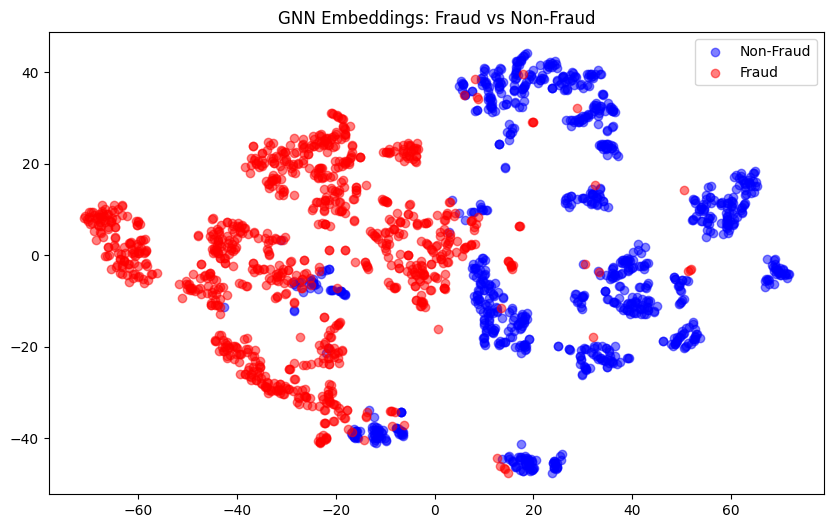

In [ ]:
# 1. Check actual training class ratio
n_pos_train = (train_data["transaction"].y == 1).sum().item()
n_neg_train = (train_data["transaction"].y == 0).sum().item()
actual_ratio = n_neg_train / n_pos_train

print(f"Hardcoded pos_weight: {pos_weight.item():.2f}")
print(f"Actual training ratio: {actual_ratio:.2f}")
print(f"Mismatch: {actual_ratio / pos_weight.item():.2f}x wrong")

# 2. Visualize embedding separation
import numpy as np
from sklearn.manifold import TSNE

# Get embeddings
encoder.eval()
with torch.no_grad():
    train_out = encoder(train_data.x_dict, train_data.edge_index_dict)
    fraud_emb = train_out["transaction"][train_data["transaction"].y == 1].numpy()
    nonfraud_emb = train_out["transaction"][train_data["transaction"].y == 0].numpy()

# t-SNE visualization
combined = np.vstack([fraud_emb[:1000], nonfraud_emb[:1000]])
labels = np.array([1]*1000 + [0]*1000)
tsne = TSNE(n_components=2, random_state=42)
embedded = tsne.fit_transform(combined)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(embedded[labels==0, 0], embedded[labels==0, 1], c='blue', alpha=0.5, label='Non-Fraud')
plt.scatter(embedded[labels==1, 0], embedded[labels==1, 1], c='red', alpha=0.5, label='Fraud')
plt.title("GNN Embeddings: Fraud vs Non-Fraud")
plt.legend()
plt.show()

# Save model

In [ ]:
import pickle
import torch
from google.colab import files

# 1. Save PyTorch GNN weights
torch.save(encoder.state_dict(), 'gnn_encoder_weights.pth')
torch.save(head.state_dict(), 'gnn_head_weights.pth')

# 2. Save XGBoost model
model.save_model('xgboost_model.json')

# 3. Save the Scalers, ID Mappings, AND historical node-feature tensors
#    (the two new keys fix the KeyError on load)
preprocessing_artifacts = {
    'scaler': scaler,
    'cust_scaler': cust_scaler,
    'merch_scaler': merch_scaler,
    'emb_scaler': emb_scaler,
    'customer_id_map': customer_id_map,
    'merchant_id_map': merchant_id_map,
    'feature_cols': feature_cols,
    'continuous_cols': continuous_cols,                  # was hardcoded
    'xgb_feature_cols': X_train_numeric.columns.tolist(),# column order!
    'best_threshold': best_thresh,                       # tuned threshold
    'hidden_channels': 64,
    'out_channels': 32,
    'node_types': list(train_data.node_types),
    'edge_types': list(train_data.edge_types),
    'mcc_freq': mcc_freq.to_dict(),                      # MCC frequency map
    'node_feature_cols': [
        "mean_amount","std_amount","txn_count","fraud_rate",
        "night_txn_ratio","avg_hour","mcc_diversity",
        "error_rate","online_ratio","swipe_ratio",
    ],
    'train_customer_x': train_customer_x.detach().cpu(),
    'train_merchant_x': train_merchant_x.detach().cpu(),
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(preprocessing_artifacts, f)

# Also persist the tensors as standalone .pt files (robust fallback if
# the pickle ever fails to unpickle across torch versions)
torch.save(train_customer_x.detach().cpu(), 'train_customer_x.pt')
torch.save(train_merchant_x.detach().cpu(), 'train_merchant_x.pt')

# Save the historical node feature tensors!

print("All models and artifacts saved!")

files.download('gnn_encoder_weights.pth')
files.download('gnn_head_weights.pth')
files.download('xgboost_model.json')
files.download('preprocessing_artifacts.pkl')
files.download('train_customer_x.pt')
files.download('train_merchant_x.pt')

All models and artifacts saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>